## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('[INFO] Google Drive mounted successfully.')

Mounted at /content/drive
[INFO] Google Drive mounted successfully.


## 2. Install Required Libraries

In [2]:
!pip install transformers datasets scikit-learn matplotlib seaborn pandas numpy torch
print('[INFO] Required libraries installed.')

[INFO] Required libraries installed.


## 3. Define Paths and Create Directories

In [3]:
import os

# Update path sesuai permintaan untuk Google Drive
DATA_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/data"
MODEL_OUTPUT_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/models/category_model_checkpoints"
FINAL_MODEL_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final"

# Pastikan folder output tersedia
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print(f"[INFO] Path data diatur ke: {DATA_DIR}")
print(f"[INFO] Output model sementara di: {MODEL_OUTPUT_DIR}")
print(f"[INFO] Output model final di: {FINAL_MODEL_DIR}")

[INFO] Path data diatur ke: /content/drive/MyDrive/TugasMachineLearning/project akhir/data
[INFO] Output model sementara di: /content/drive/MyDrive/TugasMachineLearning/project akhir/models/category_model_checkpoints
[INFO] Output model final di: /content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final


## 4. Script Overview and Initial Setup

In [4]:
print("================================================================================")
print("SMART CAMPUS HELPDESK - URGENCY MODEL TRAINING SCRIPT")
print("Universitas Halu Oleo (UHO) - Tugas Akhir Machine Learning")
print("================================================================================")
print("Fungsi: Melakukan fine-tuning model IndoBERT (indobenchmark/indobert-base-p1)")
print("        untuk mengklasifikasikan 4 Tingkat Urgensi Laporan Keluhan.")
print("        Mengatasi Class Imbalance berat (kelas KRITIS) menggunakan Weighted Loss.")
print("Metrik Evaluasi Utama: Macro F1-Score")
print("================================================================================")

SMART CAMPUS HELPDESK - URGENCY MODEL TRAINING SCRIPT
Universitas Halu Oleo (UHO) - Tugas Akhir Machine Learning
Fungsi: Melakukan fine-tuning model IndoBERT (indobenchmark/indobert-base-p1)
        untuk mengklasifikasikan 4 Tingkat Urgensi Laporan Keluhan.
        Mengatasi Class Imbalance berat (kelas KRITIS) menggunakan Weighted Loss.
Metrik Evaluasi Utama: Macro F1-Score


## 5. Import Libraries and Setup Reproducibility

In [5]:
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Reproduksibilitas (Academic-Grade Reproducibility)
def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    set_seed(seed)

setup_seed(42)
print('[INFO] Reproducibility seed set to 42.')

[INFO] Reproducibility seed set to 42.


## 6. Initialize Training Process and Load Datasets

In [6]:
print("================================================================================")
print("[INFO] MEMULAI FASE LATIH MODEL URGENSI TRIAGE (INDOBERT - WEIGHTED LOSS)")
print("================================================================================")

# 2. Muat Dataset Hasil Stratified Split
train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Berkas dataset '{path}' tidak ditemukan. Jalankan pembersihan data terlebih dahulu.")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"[OK] Berkas Data Latih Berhasil Dimuat:")
print(f"     - Train Set      : {len(train_df)} sampel")
print(f"     - Validation Set : {len(val_df)} sampel")
print(f"     - Test Set       : {len(test_df)} sampel")

[INFO] MEMULAI FASE LATIH MODEL URGENSI TRIAGE (INDOBERT - WEIGHTED LOSS)
[OK] Berkas Data Latih Berhasil Dimuat:
     - Train Set      : 1448 sampel
     - Validation Set : 181 sampel
     - Test Set       : 181 sampel


## 7. Map Urgency Labels

In [7]:
# 3. Pemetaan Label Urgensi (4 Kelas Target)
LABEL2ID = {
    'RENDAH': 0,
    'SEDANG': 1,
    'TINGGI': 2,
    'KRITIS': 3
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

train_df['label'] = train_df['urgency'].map(LABEL2ID)
val_df['label']   = val_df['urgency'].map(LABEL2ID)
test_df['label']  = test_df['urgency'].map(LABEL2ID)

print('[INFO] Labels mapped to numerical IDs.')
print('Example of label mapping:')
print(train_df[['urgency', 'label']].head())

[INFO] Labels mapped to numerical IDs.
Example of label mapping:
  urgency  label
0  TINGGI      2
1  TINGGI      2
2  RENDAH      0
3  RENDAH      0
4  RENDAH      0


## 8. Tokenization using IndoBERT Tokenizer

In [8]:
# 4. Tokenisasi Menggunakan Tokenizer IndoBERT
MODEL_NAME = "indobenchmark/indobert-base-p1"
print(f"\n[INFO] Mengunduh Tokenizer: '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

print("[INFO] Memproses tokenisasi teks keluhan...")
train_ds = Dataset.from_pandas(train_df[['text', 'label']])
val_ds   = Dataset.from_pandas(val_df[['text', 'label']])
test_ds  = Dataset.from_pandas(test_df[['text', 'label']])

train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized   = val_ds.map(tokenize_function, batched=True)
test_tokenized  = test_ds.map(tokenize_function, batched=True)

print('[OK] Datasets tokenized.')


[INFO] Mengunduh Tokenizer: 'indobenchmark/indobert-base-p1'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

...

[INFO] Memproses tokenisasi teks keluhan...


Map:   0%|          | 0/1448 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

[OK] Datasets tokenized.


## 9. Compute Class Weights for Imbalance Handling

In [9]:
# 5. Menghitung Bobot Kelas untuk Mengatasi Class Imbalance
# Menggunakan rumus balanced: total_samples / (num_classes * class_samples)
print("\n[INFO] Menghitung Vektor Bobot Kelas (Class Weights) untuk data training...")
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Konversi bobot kelas ke PyTorch Tensor
device = "cuda" if torch.cuda.is_available() else "cpu"
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"     * Sebaran Bobot Kelas:")
for label_name, label_id in LABEL2ID.items():
    print(f"       - {label_name.ljust(10)} (ID: {label_id}) -> Bobot: {class_weights[label_id]:.4f}")


[INFO] Menghitung Vektor Bobot Kelas (Class Weights) untuk data training...
     * Sebaran Bobot Kelas:
       - RENDAH     (ID: 0) -> Bobot: 0.4123
       - SEDANG     (ID: 1) -> Bobot: 1.8100
       - TINGGI     (ID: 2) -> Bobot: 1.1715
       - KRITIS     (ID: 3) -> Bobot: 5.9344


## 10. Customize WeightedTrainer for Loss Function Modification

In [10]:
# 6. Kustomisasi Kelas WeightedTrainer untuk Modifikasi Loss Function
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        # Menghitung loss menggunakan Cross Entropy berbobot
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print('[INFO] WeightedTrainer class defined for custom loss computation.')

[INFO] WeightedTrainer class defined for custom loss computation.


## 11. Load Pre-trained IndoBERT Model

In [11]:
# 7. Memuat Model Pra-Latih IndoBERT Sequence Classification
print(f"\n[INFO] Mengunduh Model Pra-Latih: '{MODEL_NAME}' untuk {len(LABEL2ID)} kelas...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print('[OK] Pre-trained IndoBERT model loaded.')


[INFO] Mengunduh Model Pra-Latih: 'indobenchmark/indobert-base-p1' untuk 4 kelas...


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[OK] Pre-trained IndoBERT model loaded.


## 12. Define Comprehensive Evaluation Metrics

In [12]:
# 8. Definisi Metrik Evaluasi Komprehensif
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average='weighted')

    return {
        'accuracy': acc,
        'f1_macro': f1,
        'f1_weighted': f1_weighted,
        'precision_macro': precision,
        'recall_macro': recall
    }

print('[INFO] `compute_metrics` function defined.')

[INFO] `compute_metrics` function defined.


## 13. Configure Training Arguments

In [13]:
# 9. Konfigurasi Argumen Pelatihan (Optimasi Google Colab T4 GPU)
print("\n[INFO] Mengonfigurasi Hyperparameter Training...")
training_args = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,               # Laju pembelajaran optimal untuk IndoBERT
    warmup_ratio=0.1,                 # Rasio pemanasan scheduler
    weight_decay=0.01,                # Regularisasi weight decay
    eval_strategy='epoch',            # Evaluasi dilakukan tiap selesai 1 epoch
    save_strategy='epoch',            # Checkpoint disimpan tiap selesai 1 epoch
    load_best_model_at_end=True,      # Memuat model terbaik otomatis setelah pelatihan selesai
    metric_for_best_model='f1_macro', # Menilai model terbaik berdasarkan Macro F1
    fp16=torch.cuda.is_available(),   # Mengaktifkan FP16 jika GPU tersedia
    logging_steps=50,
    report_to='none'                  # Menonaktifkan W&B logger
)

# Menggunakan WeightedTrainer untuk melatih model urgensi
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)

print('[OK] Training arguments and Trainer initialized.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



[INFO] Mengonfigurasi Hyperparameter Training...
[OK] Training arguments and Trainer initialized.


## 14. Execute Fine-Tuning

In [14]:
# 10. Eksekusi Fine-Tuning Model Urgensi
print("\n[INFO] Memulai Proses Training Model Urgensi (Epoch 1-5)...")
trainer.train()

print('[OK] Model fine-tuning completed.')


[INFO] Memulai Proses Training Model Urgensi (Epoch 1-5)...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,1.320645,0.649420,0.817680,0.721171,0.811667,0.764151,0.720151
2,0.422187,0.141047,0.966851,0.968772,0.966604,0.967572,0.970708
3,0.109145,0.037044,0.988950,0.988825,0.988979,0.986327,0.991451
4,0.069095,0.031068,0.994475,0.993067,0.994484,0.992424,0.993902
5,0.078730,0.021082,0.994475,0.993067,0.994484,0.992424,0.993902


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

[OK] Model fine-tuning completed.


## 15. Save the Best Trained Model

In [15]:
# 11. Menyimpan Model Terbaik Hasil Latih
print(f"\n[OK] Pelatihan selesai. Menyimpan model terbaik ke: '{FINAL_MODEL_DIR}'...")
if not os.path.exists(FINAL_MODEL_DIR):
    os.makedirs(FINAL_MODEL_DIR)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print('[OK] Best model and tokenizer saved.')


[OK] Pelatihan selesai. Menyimpan model terbaik ke: '/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[OK] Best model and tokenizer saved.


## 16. Final Evaluation on Test Set

In [16]:
# 12. Evaluasi Akhir pada Set Pengujian (Test Set - Unseen Data)
print("\n================================================================================")
print("[INFO] MEMULAI EVALUASI MODEL PADA SET PENGUJIAN (TEST SET)")
print("================================================================================")

test_results = trainer.predict(test_tokenized)
print("\nMetrik Hasil Evaluasi Test Set:")
for metric_name, val in test_results.metrics.items():
    print(f"  - {metric_name.ljust(25)}: {val:.4f}")

# Klasifikasi Prediksi untuk Laporan Akademik
y_pred = np.argmax(test_results.predictions, axis=-1)
y_true = test_df['label'].values

print("\n--- CLASSIFICATION REPORT (URGENSI) ---")
report = classification_report(
    y_true,
    y_pred,
    target_names=list(LABEL2ID.keys()),
    digits=4
)
print(report)


[INFO] MEMULAI EVALUASI MODEL PADA SET PENGUJIAN (TEST SET)



Metrik Hasil Evaluasi Test Set:
  - test_loss                : 0.2139
  - test_accuracy            : 0.9890
  - test_f1_macro            : 0.9512
  - test_f1_weighted         : 0.9882
  - test_precision_macro     : 0.9861
  - test_recall_macro        : 0.9286
  - test_runtime             : 0.3783
  - test_samples_per_second  : 478.4960
  - test_steps_per_second    : 15.8620

--- CLASSIFICATION REPORT (URGENSI) ---
              precision    recall  f1-score   support

      RENDAH     1.0000    1.0000    1.0000       112
      SEDANG     1.0000    1.0000    1.0000        28
      TINGGI     0.9444    1.0000    0.9714        34
      KRITIS     1.0000    0.7143    0.8333         7

    accuracy                         0.9890       181
   macro avg     0.9861    0.9286    0.9512       181
weighted avg     0.9896    0.9890    0.9882       181



## 17. Visualize Confusion Matrix and Final Message

[INFO] Menggambar dan menyimpan Confusion Matrix...
[OK] Visualisasi Confusion Matrix disimpan di: '/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final/urgensi_confusion_matrix.png'

[OK] SELURUH PROSES LATIH & EVALUASI MODEL URGENSI SELESAI DENGAN SUKSES!


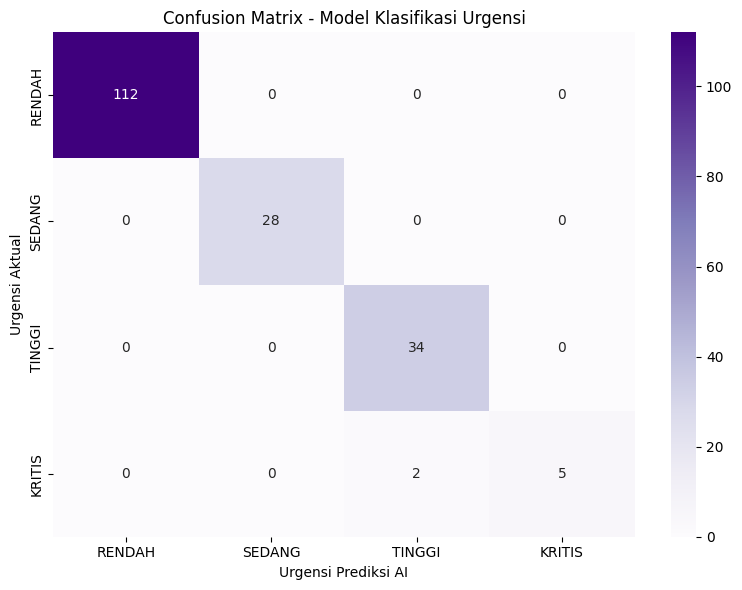

In [17]:
# Menyimpan hasil visual Confusion Matrix
try:
    print("[INFO] Menggambar dan menyimpan Confusion Matrix...")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Purples',
        xticklabels=list(LABEL2ID.keys()),
        yticklabels=list(LABEL2ID.keys())
    )
    plt.title('Confusion Matrix - Model Klasifikasi Urgensi')
    plt.ylabel('Urgensi Aktual')
    plt.xlabel('Urgensi Prediksi AI')
    plt.tight_layout()

    # Simpan plot ke models/urgensi_confusion_matrix.png
    plot_path = os.path.join(FINAL_MODEL_DIR, "urgensi_confusion_matrix.png")
    plt.savefig(plot_path, dpi=300)
    print(f"[OK] Visualisasi Confusion Matrix disimpan di: '{plot_path}'")
except Exception as e:
    print(f"[WARN] Gagal menyimpan visualisasi grafik: {e}")

print("\n================================================================================")
print("[OK] SELURUH PROSES LATIH & EVALUASI MODEL URGENSI SELESAI DENGAN SUKSES!")
print("================================================================================")

## 18. Inference with the Trained Model

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the fine-tuned model and tokenizer
print(f"[INFO] Loading fine-tuned model from: '{FINAL_MODEL_DIR}'...")
inference_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
inference_model = AutoModelForSequenceClassification.from_pretrained(FINAL_MODEL_DIR)
inference_model.to(device)
inference_model.eval()

print('[OK] Fine-tuned model and tokenizer loaded for inference.')

[INFO] Loading fine-tuned model from: '/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final'...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[OK] Fine-tuned model and tokenizer loaded for inference.


In [19]:
def predict_urgency(text, tokenizer, model, id2label, device):
    inputs = tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()
    predicted_label = id2label[prediction]
    return predicted_label

print('[INFO] `predict_urgency` function defined.')

[INFO] `predict_urgency` function defined.


### Example Inference

In [21]:
example_texts = [
    "Internet di kampus mati total, tidak bisa mengerjakan tugas.",
    "Kantin kampus tutup lebih awal, tidak bisa beli makan malam.",
    "spada mati padahala ada deadline 12 jam lagi",
    "AC di kelas tidak dingin, membuat suasana belajar tidak nyaman."
]

print("\n[INFO] Melakukan inferensi untuk teks contoh:")
for i, text in enumerate(example_texts):
    predicted_urgency = predict_urgency(text, inference_tokenizer, inference_model, ID2LABEL, device)
    print(f"  - Teks {i+1}: '{text}'\n    Prediksi Urgensi: {predicted_urgency}")

print('\n[OK] Inference examples completed.')


[INFO] Melakukan inferensi untuk teks contoh:
  - Teks 1: 'Internet di kampus mati total, tidak bisa mengerjakan tugas.'
    Prediksi Urgensi: KRITIS
  - Teks 2: 'Kantin kampus tutup lebih awal, tidak bisa beli makan malam.'
    Prediksi Urgensi: RENDAH
  - Teks 3: 'spada mati padahala ada deadline 12 jam lagi'
    Prediksi Urgensi: KRITIS
  - Teks 4: 'AC di kelas tidak dingin, membuat suasana belajar tidak nyaman.'
    Prediksi Urgensi: RENDAH

[OK] Inference examples completed.
